In [5]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [6]:
N = 6
wd = 0.6365091993031
wm = 1.0
freq_dis = 0.00
indv_qubit = False
t_max = 200
tlist = np.linspace(0, t_max, 400)
reals = 300
rand = True
z_ham = False
dis = 0.3

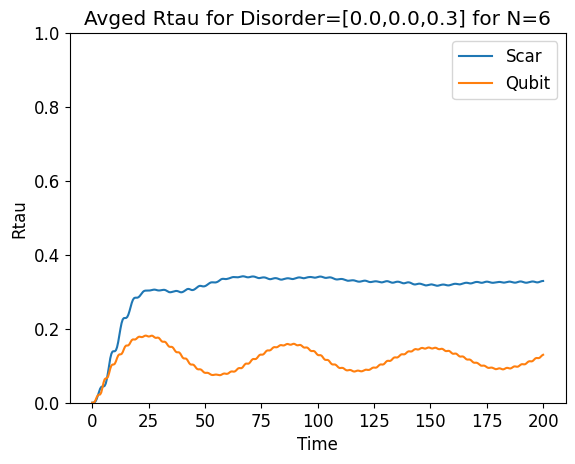

C:\Users\idden\AppData\Local\Temp\ipykernel_17416\3491531213.py:53: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, xfull_scar / xfull_qubit)


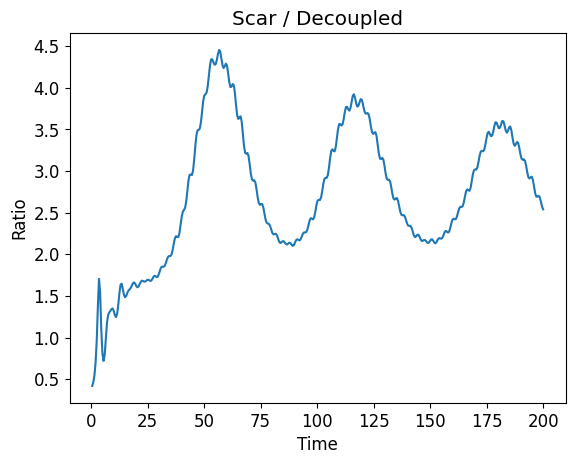

In [7]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

xfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, xfull_scar / xfull_qubit)
plt.show()

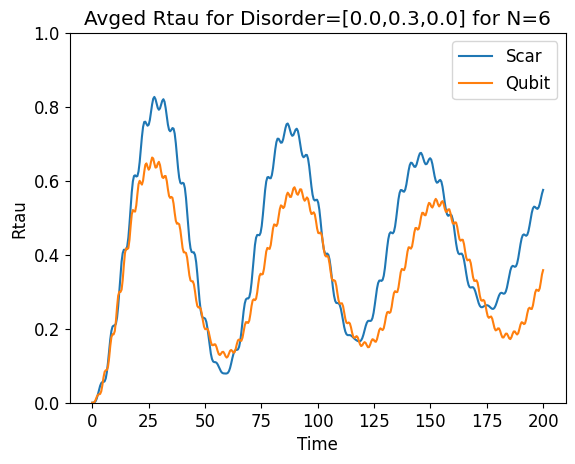

C:\Users\idden\AppData\Local\Temp\ipykernel_17416\2263159749.py:53: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, yfull_scar / yfull_qubit)


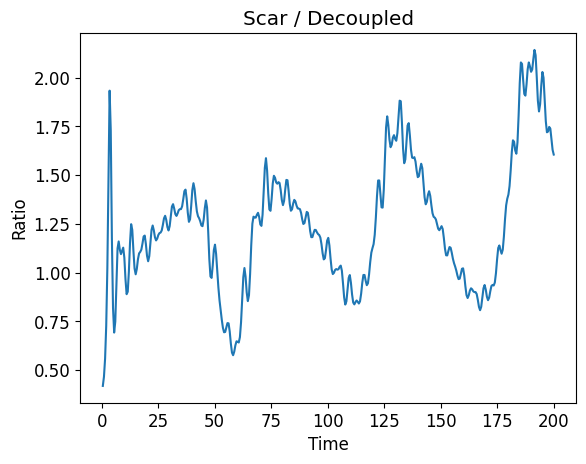

In [8]:
dz = 0.0
dy = dis
dx = 0.0

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

yfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

yfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, yfull_scar, label="Scar")
plt.plot(tlist, yfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, yfull_scar / yfull_qubit)
plt.show()

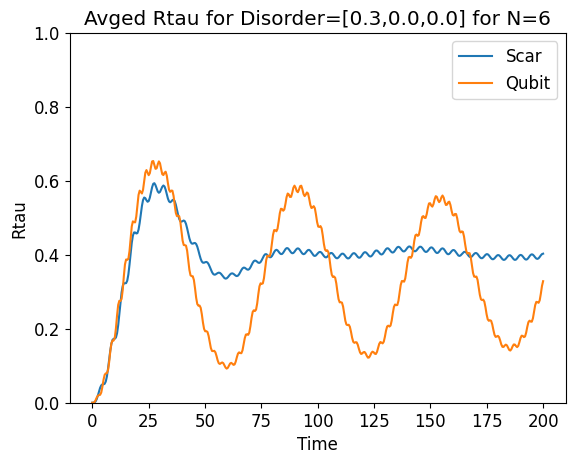

C:\Users\idden\AppData\Local\Temp\ipykernel_17416\3043697776.py:53: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, zfull_scar / zfull_qubit)


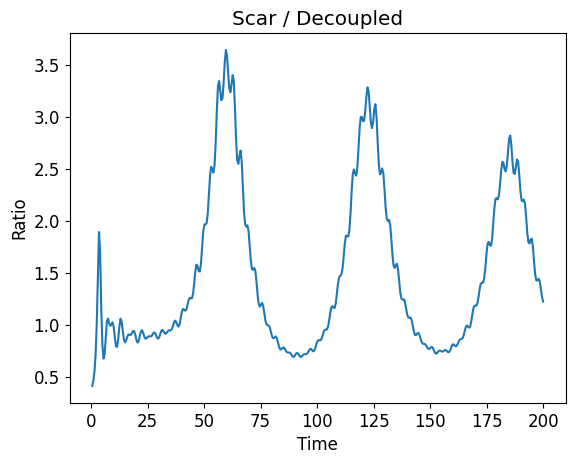

In [9]:
dz = dis
dy = 0.0
dx = 0.0

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

zfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

zfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, zfull_scar, label="Scar")
plt.plot(tlist, zfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, zfull_scar / zfull_qubit)
plt.show()

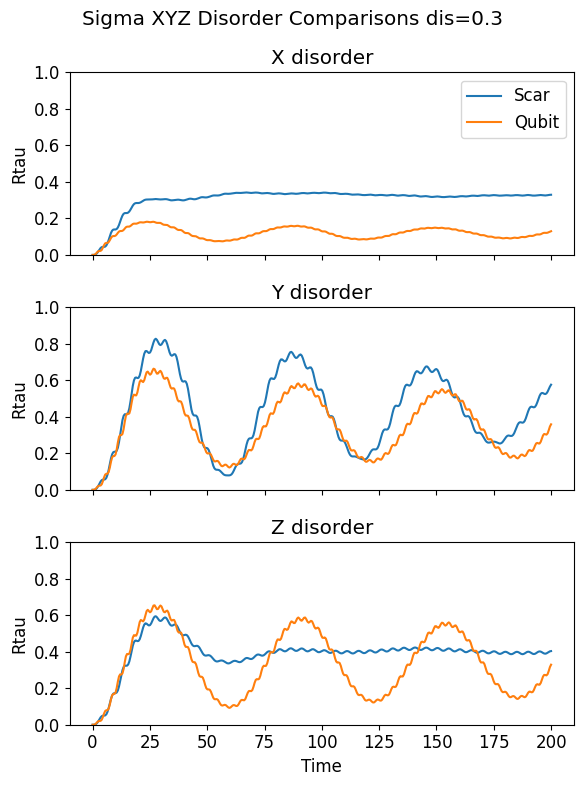

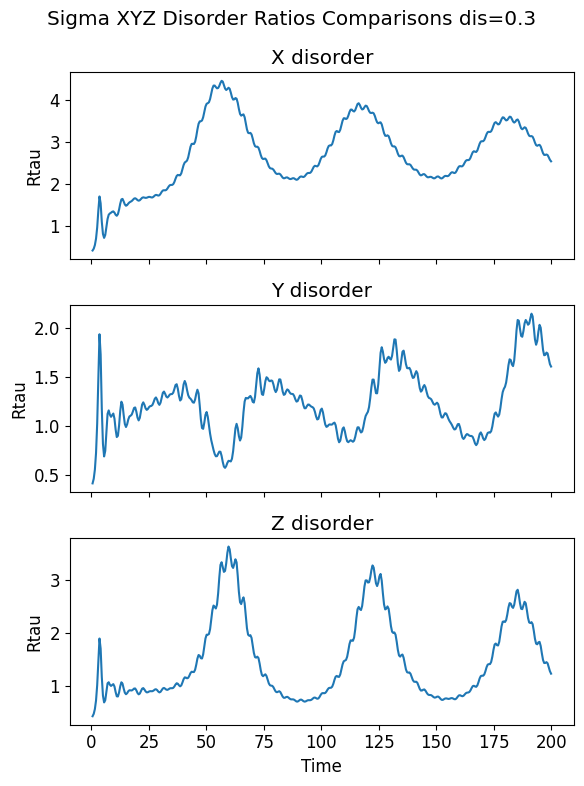

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Comparisons dis=0.3")

axs[0].plot(tlist, xfull_scar, label="Scar")
axs[0].plot(tlist, xfull_qubit, label="Qubit")
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")
axs[0].legend()

axs[1].plot(tlist, yfull_scar, label="Scar")
axs[1].plot(tlist, yfull_qubit, label="Qubit")
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist, zfull_scar, label="Scar")
axs[2].plot(tlist, zfull_qubit, label="Qubit")
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)
axs[2].set_ylim(0, 1)

plt.savefig(f"figures/xyz_N{N}_dis{dis}_reals{reals}.pdf")
plt.tight_layout()
plt.show()


fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Ratios Comparisons dis=0.3")

axs[0].plot(tlist[1:], xfull_scar[1:] / xfull_qubit[1:])
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")

axs[1].plot(tlist[1:], yfull_scar[1:] / yfull_qubit[1:])
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist[1:], zfull_scar[1:] / zfull_qubit[1:])
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

plt.tight_layout()
plt.show()